In [1]:
!pip install gensim

In [2]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 22.7 MB/s eta 0:00:00


In [3]:
import pandas as pd

import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

import spacy
import string
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
import matplotlib.pyplot as plt

import pyLDAvis
import pyLDAvis.gensim

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [4]:
# remove stopwords, punctuation, and normalize the corpus
stop = set(stopwords.words('english'))

In [5]:
df = pd.read_csv('./reviews_cleaned.csv')
df.head()

,Unnamed: 0,URL_ID,GIG_LINK,REVIEW_ID,RATING,CONTENT
0,0,27361,/sazzadedits/do-professional-youtube-video-edi...,21922,5,Always doing stop work for me.. I stopped gett...
1,1,27361,/sazzadedits/do-professional-youtube-video-edi...,21923,5,Best Youtube editor on Fiverr. I vetted so man...
2,2,27361,/sazzadedits/do-professional-youtube-video-edi...,21924,5,Working with Sazzad was fantastic. He really g...
3,3,27361,/sazzadedits/do-professional-youtube-video-edi...,21925,5,He did a very good job with the edit of my You...
4,4,27364,/sm_way/design-a-custom-logo-animation,21935,5,Serge has done it again! We had to create our ...


In [6]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
def lemmatization(text, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
  doc = nlp(text)
  new_text = []
  for token in doc:
    if token.pos_ in allowed_postags:
      new_text.append(token.lemma_)
  final = " ".join(new_text)
  return final

In [7]:
df['LEMMATIZED_CONTENT'] = df['CONTENT'].apply(lemmatization)

In [8]:
df['LEMMATIZED_CONTENT'].head()

,LEMMATIZED_CONTENT
0,always do stop work stop get video edit while ...
1,editor vet so many editor sazzad consistently ...
2,work fantastic really get fast also high quali...
3,very good job edit video thumbnail as well ani...
4,do again create very first brand video help ab...


In [9]:
def remove_stopwords(text):
  result = []
  for token in simple_preprocess(text, deacc=True):
    if token not in stop:
      result.append(token)
  return result

In [10]:
df['LEMMATIZED_CONTENT'] = df['LEMMATIZED_CONTENT'].apply(remove_stopwords)

In [11]:
#Bigrams and Trigrams
bigrams_phrases = gensim.models.Phrases(df['LEMMATIZED_CONTENT'].to_list(), min_count=5, threshold=100)
trigrams_phrases = gensim.models.Phrases(bigrams_phrases[df['LEMMATIZED_CONTENT'].to_list()], threshold=100)

bigram = gensim.models.phrases.Phraser(bigrams_phrases)
trigram = gensim.models.phrases.Phraser(trigrams_phrases)

def make_bigrams(texts):
  return [bigram[doc] for doc in texts]

def make_trigrams(texts):
  return [trigram[bigram[doc]] for doc in texts]

data_bigrams = make_bigrams(df['LEMMATIZED_CONTENT'].to_list())
data_bigrams_trigrams = make_trigrams(data_bigrams)

print(data_bigrams_trigrams)

[['always', 'stop', 'work', 'stop', 'get', 'video', 'edit', 'tank', 'first', 'edit', 'video', 'get', 'view', 'get', 'video', 'good', 'editing', 'make', 'difference'], ['editor', 'vet', 'many', 'editor', 'sazzad', 'consistently', 'deliver', 'exceptional', 'work', 'always', 'deliver', 'time', 'revision', 'fulfil', 'immediately', 'find', 'good', 'editor'], ['work', 'fantastic', 'really', 'get', 'fast', 'also', 'high', 'quality', 'look', 'forward', 'keep', 'rotation', 'editor', 'company', 'highly', 'recommend', 'thank'], ['good', 'job', 'edit', 'video', 'thumbnail', 'well', 'animation', 'sound', 'design', 'video', 'great', 'make', 'client', 'video', 'look', 'professional', 'even', 'super', 'use', 'camera', 'use', 'move', 'forward'], ['create', 'first', 'brand', 'video', 'help', 'able', 'bring', 'life', 'communicative', 'helpful', 'creative', 'overall', 'wonderful', 'partner', 'mention', 'always', 'come', 'back', 'animation', 'need', 'team'], ['happy', 'work', 'work', 'twice', 'time', 'blow

In [12]:
#TF-IDF Removal
from gensim.models import TfidfModel

id2word = corpora.Dictionary(data_bigrams_trigrams)

texts = data_bigrams_trigrams

corpus = [id2word.doc2bow(text) for text in texts]

tfidf = TfidfModel(corpus, id2word=id2word)

low_value = 0.10
words = []
words_missing_in_tfidf = []
for i in range(0, len(corpus)):
  bow = corpus[i]
  low_value_words = []
  tfidf_ids = [id for id, value in tfidf[bow]]
  bow_ids = [id for id, value in bow]
  low_value_words = [id for id, value in tfidf[bow] if value < low_value]
  drops = low_value_words + words_missing_in_tfidf
  for item in drops:
    words.append(id2word[item])
  words_missing_in_tfidf = [id for id in bow_ids if id not in tfidf_ids]
  new_bow = [b for b in bow if b[0] not in low_value_words and b[0] not in words_missing_in_tfidf]
  corpus[i] = new_bow


Number of Topics: 4
Number of Topics: 5
Number of Topics: 6
Number of Topics: 7
Number of Topics: 8
Number of Topics: 9
Number of Topics: 10
Number of Topics: 11
Number of Topics: 12
Number of Topics: 13
Number of Topics: 14
Number of Topics: 15
Number of Topics: 16
Number of Topics: 17
Number of Topics: 18
Number of Topics: 19
Number of Topics: 20
Number of Topics: 21
Number of Topics: 22
Number of Topics: 23
Number of Topics: 24


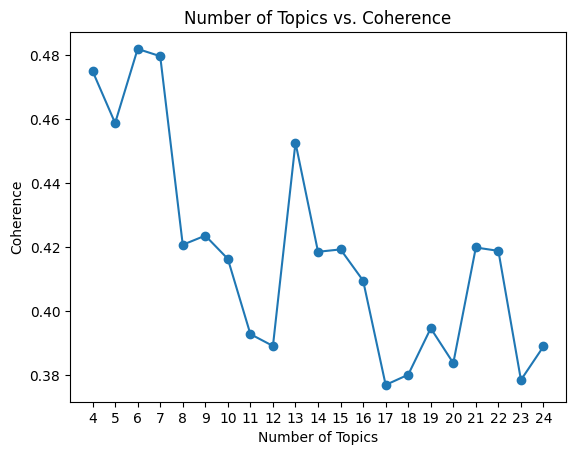

In [13]:
coherence = []
for k in range(4, 25):
  print(f'Number of Topics: {str(k)}')
  lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=id2word, num_topics=k, iterations=200, update_every=1, chunksize=1000, passes=20, alpha='auto')
  cm = gensim.models.coherencemodel.CoherenceModel(model=lda_model, texts=data_bigrams_trigrams, dictionary=id2word, coherence='c_v')
  coherence.append((k, cm.get_coherence()))
x_val = [x[0] for x in coherence]
y_val = [x[1] for x in coherence]
plt.plot(x_val,y_val)
plt.scatter(x_val,y_val)
plt.title('Number of Topics vs. Coherence')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence')
plt.xticks(x_val)
plt.show()

In [16]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=id2word, num_topics=13, iterations=200, update_every=1, chunksize=1000, passes=20, alpha='auto')

In [17]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds='mmds', R=25)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6      0.121267 -0.112263       1        1  33.094798
9      0.027239 -0.487145       2        1  22.556278
4     -0.122459 -0.355464       3        1   9.691677
2     -0.222513  0.423126       4        1   5.293198
7      0.318214 -0.338567       5        1   5.047619
0      0.446061 -0.084673       6        1   4.044297
5      0.059761  0.440257       7        1   3.358506
12    -0.368281 -0.273847       8        1   3.224235
11    -0.418116  0.185684       9        1   3.177231
8      0.263878  0.333025      10        1   2.844440
1      0.394569  0.155977      11        1   2.836634
10    -0.111183  0.156256      12        1   2.832408
3     -0.388438 -0.042366      13        1   1.998679, topic_info=          Term         Freq        Total Category  logprob  loglift
44       great  4030.000000  4030.000000  Default  25.0000  25.0000
12        work  3927.000000  3927.000000  Default  24.0000  24.0000
6         good  3152.000000  3152.000000  Default  23.0000  23.0000
38       thank  3169.000000  3169.000000  Default  22.0000  22.0000
0       always  2651.000000  2651.000000  Default  21.0000  21.0000
...        ...          ...          ...      ...      ...      ...
1025  flawless    67.559507    68.511777  Topic13  -4.4174   3.8987
503     budget    66.752472    67.704743  Topic13  -4.4294   3.8985
1242    manner    66.738914    67.691186  Topic13  -4.4296   3.8985
505        low    65.061357    66.013627  Topic13  -4.4551   3.8982
1575      text    64.465971    65.418244  Topic13  -4.4642   3.8980

[383 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
128       3  0.997586     absolute
80        1  0.033288   absolutely
80        2  0.965352   absolutely
644       9  0.990845      account
742       7  0.991819     accurate
...     ...       ...          ...
677       4  0.984061  willingness
1097      5  0.993054         word
12        5  0.999701         work
1057      8  0.990887        world
517       7  0.993205         year

[386 rows x 3 columns], R=25, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 10, 5, 3, 8, 1, 6, 13, 12, 9, 2, 11, 4])